In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cấu hình hiển thị giao diện đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Tải dữ liệu Iris
df = sns.load_dataset("iris")

In [2]:
# Hiển thị 5 dòng đầu
print("--- 5 DÒNG ĐẦU TIÊN ---")
print(df.head())

# Số dòng, số cột
print("\n--- CẤU TRÚC DỮ LIỆU ---")
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
print(f"Danh sách các cột: {list(df.columns)}")
print(f"Kiểu dữ liệu của từng cột:\n{df.dtypes}")

--- 5 DÒNG ĐẦU TIÊN ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- CẤU TRÚC DỮ LIỆU ---
Số dòng: 150, Số cột: 5
Danh sách các cột: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Kiểu dữ liệu của từng cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [3]:
print("\n--- THỐNG KÊ MÔ TẢ CHI TIẾT ---")
numeric_cols = df.select_dtypes(include=[np.number]).columns

metrics = {}
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    metrics[col] = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode()[0], # Lấy giá trị mode đầu tiên nếu có nhiều mode
        'Variance': df[col].var(),
        'Std Dev': df[col].std(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr
    }

df_metrics = pd.DataFrame(metrics)
print(df_metrics.round(4))


--- THỐNG KÊ MÔ TẢ CHI TIẾT ---
          sepal_length  sepal_width  petal_length  petal_width
Mean            5.8433       3.0573        3.7580       1.1993
Median          5.8000       3.0000        4.3500       1.3000
Mode            5.0000       3.0000        1.4000       0.2000
Variance        0.6857       0.1900        3.1163       0.5810
Std Dev         0.8281       0.4359        1.7653       0.7622
Min             4.3000       2.0000        1.0000       0.1000
Max             7.9000       4.4000        6.9000       2.5000
Q1              5.1000       2.8000        1.6000       0.3000
Q3              6.4000       3.3000        5.1000       1.8000
IQR             1.3000       0.5000        3.5000       1.5000


In [4]:
print("\n--- THỐNG KÊ THEO TỪNG NHÓM LOÀI (SPECIES) ---")
groupby_metrics = df.groupby('species').agg(['mean', 'std'])
print(groupby_metrics.round(4))


--- THỐNG KÊ THEO TỪNG NHÓM LOÀI (SPECIES) ---
           sepal_length         sepal_width         petal_length          \
                   mean     std        mean     std         mean     std   
species                                                                    
setosa            5.006  0.3525       3.428  0.3791        1.462  0.1737   
versicolor        5.936  0.5162       2.770  0.3138        4.260  0.4699   
virginica         6.588  0.6359       2.974  0.3225        5.552  0.5519   

           petal_width          
                  mean     std  
species                         
setosa           0.246  0.1054  
versicolor       1.326  0.1978  
virginica        2.026  0.2747  


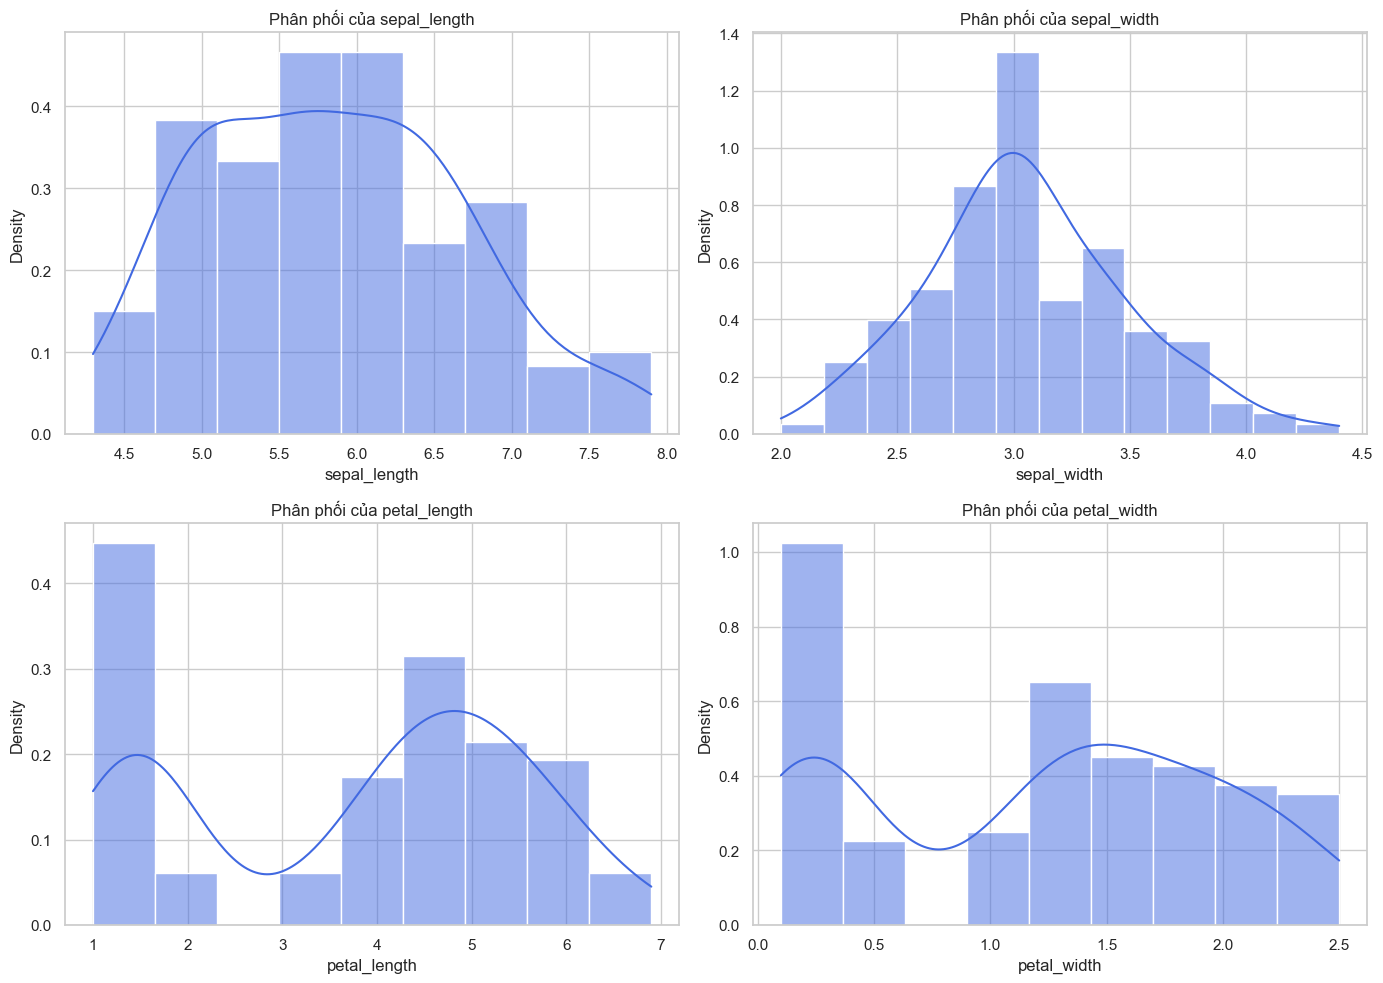

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue', stat="density")
    axes[i].set_title(f"Phân phối của {col}")

plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_23652\2810020698.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=axes[i], palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_23652\2810020698.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=axes[i], palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_23652\2810020698.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=axes[i], palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipy

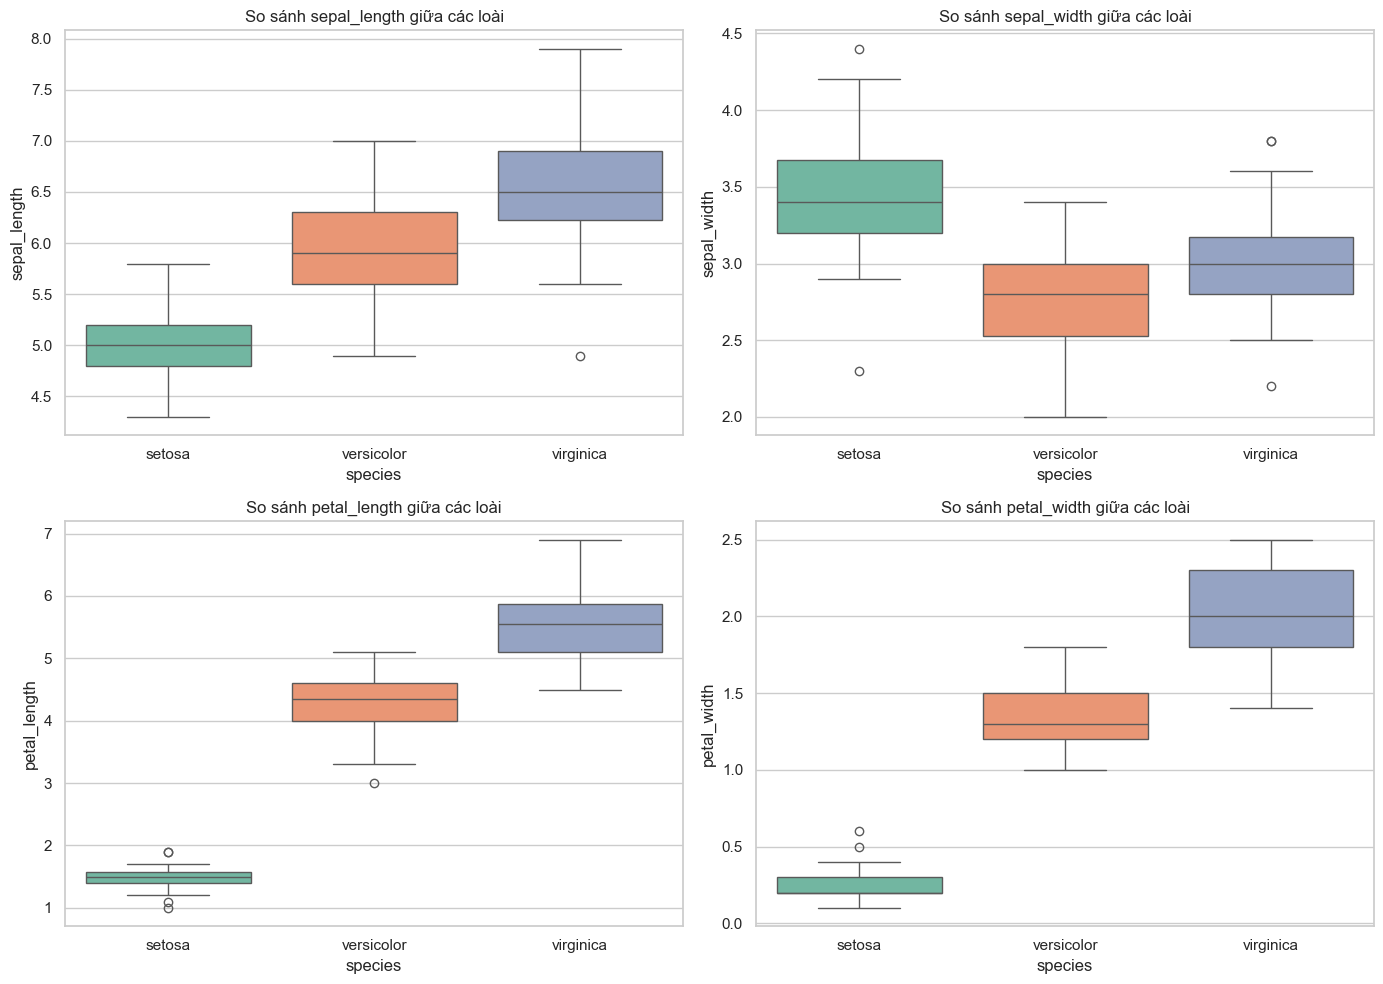

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='species', y=col, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"So sánh {col} giữa các loài")

plt.tight_layout()
plt.show()

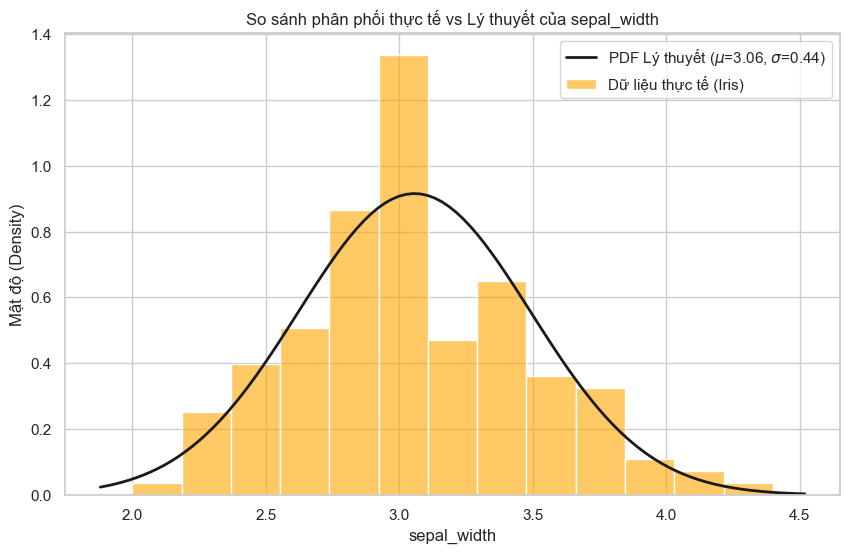

In [7]:
chosen_col = 'sepal_width'
mu = df[chosen_col].mean()
sigma = df[chosen_col].std()

# Sinh mẫu ngẫu nhiên từ phân phối Normal lý thuyết
simulated_data = np.random.normal(mu, sigma, 10000)

# Vẽ đồ thị chồng nhau
plt.figure(figsize=(10, 6))
sns.histplot(df[chosen_col], stat="density", alpha=0.6, label="Dữ liệu thực tế (Iris)", color="orange")

# Vẽ đường cong PDF lý thuyết
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, sigma)
plt.plot(x, p, 'k', linewidth=2, label=f"PDF Lý thuyết ($\mu$={mu:.2f}, $\sigma$={sigma:.2f})")

plt.title(f"So sánh phân phối thực tế vs Lý thuyết của {chosen_col}")
plt.xlabel(chosen_col)
plt.ylabel("Mật độ (Density)")
plt.legend()
plt.show()

--- MA TRẬN HIỆP PHƯƠNG SAI ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length        0.6857      -0.0424        1.2743       0.5163
sepal_width        -0.0424       0.1900       -0.3297      -0.1216
petal_length        1.2743      -0.3297        3.1163       1.2956
petal_width         0.5163      -0.1216        1.2956       0.5810

--- MA TRẬN TƯƠNG QUAN ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length        1.0000      -0.1176        0.8718       0.8179
sepal_width        -0.1176       1.0000       -0.4284      -0.3661
petal_length        0.8718      -0.4284        1.0000       0.9629
petal_width         0.8179      -0.3661        0.9629       1.0000


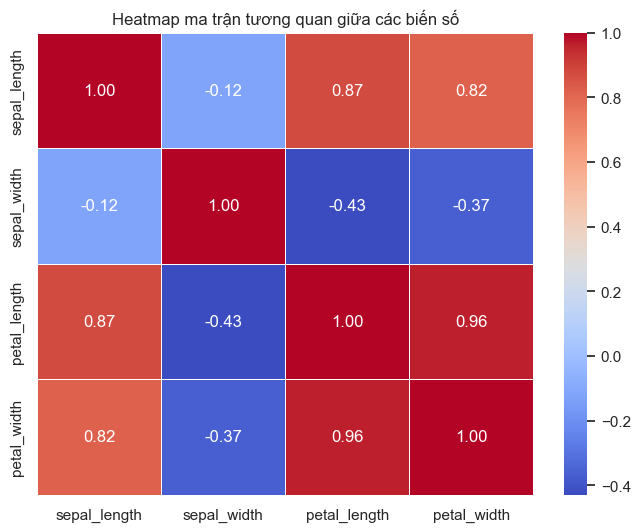

In [8]:
# Ma trận hiệp phương sai
cov_matrix = df[numeric_cols].cov()
print("--- MA TRẬN HIỆP PHƯƠNG SAI ---")
print(cov_matrix.round(4))

# Ma trận tương quan
corr_matrix = df[numeric_cols].corr()
print("\n--- MA TRẬN TƯƠNG QUAN ---")
print(corr_matrix.round(4))

# Vẽ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap ma trận tương quan giữa các biến số")
plt.show()